In [2]:
import torch 
import torch.nn.functional as F 

In [12]:
a = torch.tensor([1,2],dtype=torch.float16)
print(a.dtype)
print(a.float().dtype)

torch.float16
torch.float32


In [2]:
import torch.nn as nn 
import torch.optim as optim
model = nn.Linear(2,3)

model.state_dict()
optimizer = optim.SGD(model.parameters(),lr = 0.03)

optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.03,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

# Path

In [2]:
from pathlib import Path 

In [3]:
config_path = Path("cfgs/default.yaml")
config_path

PosixPath('cfgs/default.yaml')

In [5]:
if not config_path.exists(): 
    raise FileNotFoundError(f"config file not found")

In [6]:
config_path.name

'default.yaml'

In [11]:
some_path = Path("experiments/model_A_seed")
some_path.name.rsplit("_seed",1)[0]

'model_A'

# OmegaConf

- `OmegaConf` allows you to use dot notation, unlike `yaml.safe_load()`

In [4]:
from omegaconf import OmegaConf,DictConfig

cfg = OmegaConf.load(config_path)
cfg

{'meta': {'seed': 42, 'device': 'auto'}, 'data': {'dataset': 'cifar10', 'batch_size': 256, 'num_workers': 4}, 'model': {'type': 'resnet', 'patch_size': 2, 'use_projector': True, 'proj_hidden_dim': 2048, 'proj_output_dim': 2048}, 'loss': {'type': 'vicreg', 'std_coeff': 1.0, 'cov_coeff': 80.0, 'lmbd': 10.0}, 'optim': {'epochs': 300, 'lr': 0.3, 'weight_decay': 0.0001, 'warmup_epochs': 10, 'warmup_start_lr': 3e-05, 'min_lr': 0.0}, 'logging': {'log_wandb': True, 'wandb_group': None, 'log_every': 10, 'save_every': 50, 'tqdm_silent': False}, 'training': {'use_amp': True, 'dtype': 'bfloat16'}, 'sweep': {'param_grid': {'data.batch_size': [256], 'model.use_projector': [True, False], 'model.proj_hidden_dim': [64, 128, 256, 512, 1024, 2048, 4096], 'model.proj_output_dim': [64, 128, 256, 512, 1024, 2048, 4096], 'loss.std_coeff': [1.0, 10.0, 100.0], 'loss.cov_coeff': [0.1, 1.0, 10.0, 100.0], 'meta.seed': [1, 1000, 10000]}}}

In [5]:
from pathlib import Path 

directory = "somefolder/subfolder"

Path(directory).mkdir(parents= True, exist_ok=True)

# BCS 

In [1]:
import torch 

In [29]:
num_slices = 256  # number of random directions we test for Gaussianity
B = 32 # batch size 
proj_output_dim = 2048
z1 = torch.randn(B,proj_output_dim)
z2 = torch.randn(B,proj_output_dim)


g = torch.Generator()
g.manual_seed(0)
proj_shape = (z1.size(1),num_slices)    

A = torch.randn(proj_shape,generator=g) # (proj_output_dim, num_slices)
A /= A.norm(p=2,dim=0) 

view1 = z1 @ A  # (B,proj_output_dim) @ (proj_output_dim,num_slices)
view2 = z2 @ A 

print(view1.shape)  # (B,num_slices)

torch.Size([32, 256])


### `epps_pully`

In [30]:
t_min,t_max = -3,3
n_points = 10 

t = torch.linspace(t_min,t_max,n_points)
exp_f = torch.exp(-0.5 * t**2) # CF(t) = e^(-t²/2)

exp_f

tensor([0.0111, 0.0657, 0.2494, 0.6065, 0.9460, 0.9460, 0.6065, 0.2494, 0.0657,
        0.0111])

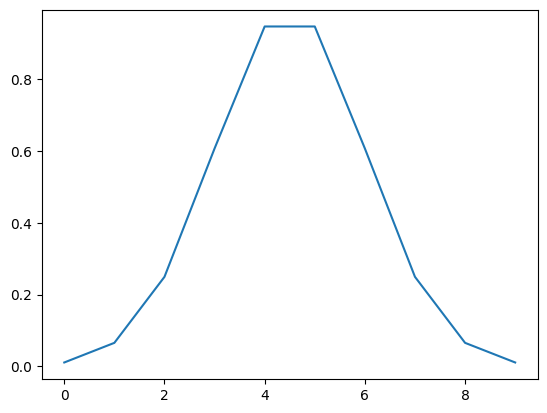

In [31]:
import matplotlib.pyplot as plt
plt.plot(exp_f)

In [32]:
x_t = view1.unsqueeze(2) * t # from (N,M) --->  (N, M, T) 

# (N, M, T) is (batchsize,num_slices,number of integration points n_points)

In [33]:
x_t.shape 

torch.Size([32, 256, 10])

In [34]:
x_t

tensor([[[-2.1379, -1.6628, -1.1877,  ...,  1.1877,  1.6628,  2.1379],
         [-2.9828, -2.3199, -1.6571,  ...,  1.6571,  2.3199,  2.9828],
         [ 5.6454,  4.3909,  3.1364,  ..., -3.1364, -4.3909, -5.6454],
         ...,
         [ 2.3400,  1.8200,  1.3000,  ..., -1.3000, -1.8200, -2.3400],
         [-1.8358, -1.4279, -1.0199,  ...,  1.0199,  1.4279,  1.8358],
         [-5.2600, -4.0911, -2.9222,  ...,  2.9222,  4.0911,  5.2600]],

        [[ 3.3246,  2.5858,  1.8470,  ..., -1.8470, -2.5858, -3.3246],
         [-3.7872, -2.9456, -2.1040,  ...,  2.1040,  2.9456,  3.7872],
         [-1.6563, -1.2883, -0.9202,  ...,  0.9202,  1.2883,  1.6563],
         ...,
         [-1.6152, -1.2562, -0.8973,  ...,  0.8973,  1.2562,  1.6152],
         [ 1.5881,  1.2352,  0.8823,  ..., -0.8823, -1.2352, -1.5881],
         [ 3.4210,  2.6608,  1.9006,  ..., -1.9006, -2.6608, -3.4210]],

        [[ 3.3716,  2.6224,  1.8731,  ..., -1.8731, -2.6224, -3.3716],
         [ 5.7288,  4.4557,  3.1827,  ..., -3

In [35]:
1j * x_t

tensor([[[-0.-2.1379j, -0.-1.6628j, -0.-1.1877j,  ..., 0.+1.1877j, 0.+1.6628j,
          0.+2.1379j],
         [-0.-2.9828j, -0.-2.3199j, -0.-1.6571j,  ..., 0.+1.6571j, 0.+2.3199j,
          0.+2.9828j],
         [0.+5.6454j, 0.+4.3909j, 0.+3.1364j,  ..., -0.-3.1364j, -0.-4.3909j,
          -0.-5.6454j],
         ...,
         [0.+2.3400j, 0.+1.8200j, 0.+1.3000j,  ..., -0.-1.3000j, -0.-1.8200j,
          -0.-2.3400j],
         [-0.-1.8358j, -0.-1.4279j, -0.-1.0199j,  ..., 0.+1.0199j, 0.+1.4279j,
          0.+1.8358j],
         [-0.-5.2600j, -0.-4.0911j, -0.-2.9222j,  ..., 0.+2.9222j, 0.+4.0911j,
          0.+5.2600j]],

        [[0.+3.3246j, 0.+2.5858j, 0.+1.8470j,  ..., -0.-1.8470j, -0.-2.5858j,
          -0.-3.3246j],
         [-0.-3.7872j, -0.-2.9456j, -0.-2.1040j,  ..., 0.+2.1040j, 0.+2.9456j,
          0.+3.7872j],
         [-0.-1.6563j, -0.-1.2883j, -0.-0.9202j,  ..., 0.+0.9202j, 0.+1.2883j,
          0.+1.6563j],
         ...,
         [-0.-1.6152j, -0.-1.2562j, -0.-0.8973j,  ..

In [ ]:
(1j * x_t).exp()

single_ecf = (1j * x_t).exp()
single_ecf

tensor([[[-0.5372-0.8435j, -0.0919-0.9958j,  0.3738-0.9275j,  ...,
           0.3738+0.9275j, -0.0919+0.9958j, -0.5372+0.8435j],
         [-0.9874-0.1582j, -0.6810-0.7323j, -0.0862-0.9963j,  ...,
          -0.0862+0.9963j, -0.6810+0.7323j, -0.9874+0.1582j],
         [ 0.8034-0.5954j, -0.3160-0.9488j, -1.0000+0.0052j,  ...,
          -1.0000-0.0052j, -0.3160+0.9488j,  0.8034+0.5954j],
         ...,
         [-0.6956+0.7184j, -0.2467+0.9691j,  0.2675+0.9636j,  ...,
           0.2675-0.9636j, -0.2467-0.9691j, -0.6956-0.7184j],
         [-0.2619-0.9651j,  0.1424-0.9898j,  0.5234-0.8521j,  ...,
           0.5234+0.8521j,  0.1424+0.9898j, -0.2619+0.9651j],
         [ 0.5207+0.8538j, -0.5821+0.8132j, -0.9760-0.2176j,  ...,
          -0.9760+0.2176j, -0.5821-0.8132j,  0.5207-0.8538j]],

        [[-0.9833-0.1820j, -0.8495+0.5276j, -0.2727+0.9621j,  ...,
          -0.2727-0.9621j, -0.8495-0.5276j, -0.9833+0.1820j],
         [-0.7987+0.6017j, -0.9809-0.1947j, -0.5083-0.8612j,  ...,
          -0.5

In [51]:
(1j * x_t).exp().mean(0)        # (e^ix) .mean

tensor([[ 0.0217+0.1431j,  0.1619+0.0998j,  0.3692+0.0727j,  ...,
          0.3692-0.0727j,  0.1619-0.0998j,  0.0217-0.1431j],
        [-0.1200-0.1636j, -0.0939-0.1020j,  0.1900-0.0370j,  ...,
          0.1900+0.0370j, -0.0939+0.1020j, -0.1200+0.1636j],
        [-0.0131-0.0054j,  0.0369-0.0289j,  0.2434+0.0377j,  ...,
          0.2434-0.0377j,  0.0369+0.0289j, -0.0131+0.0054j],
        ...,
        [ 0.0656+0.0144j,  0.2117-0.1659j,  0.3278-0.1701j,  ...,
          0.3278+0.1701j,  0.2117+0.1659j,  0.0656-0.0144j],
        [ 0.0625+0.0362j,  0.1133-0.0241j,  0.3175-0.0916j,  ...,
          0.3175+0.0916j,  0.1133+0.0241j,  0.0625-0.0362j],
        [-0.0665+0.0087j, -0.1010-0.0129j,  0.1221-0.0795j,  ...,
          0.1221+0.0795j, -0.1010+0.0129j, -0.0665-0.0087j]])

In [52]:
(1j * x_t).exp().mean(0).shape

torch.Size([256, 10])

In [61]:
(torch.tensor(1.7242) * 1j).exp()

tensor(-0.1528+0.9883j)

In [37]:
t = torch.tensor(-2.1379)

In [ ]:
t = torch.tensor(1.7242)

real_part = torch.tensor(0.).exp 
imaginary_part = torch.cos(t) + torch.sin(t)

In [3]:
import torch 
torch.sin(- torch.tensor(torch.pi/6))

tensor(-0.5000)

In [7]:
torch.sin(torch.tensor((2 * torch.pi) + (torch.pi/6)))

tensor(0.5000)